# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS
Improving Customer Satisfaction through
**Automated Review Sentiment Analysis**

# 1. Business Objective
###Goal
The objective of this project is to build an automated Sentiment Analysis System capable of classifying
Amazon customer reviews into:

1. Positive Reviews (pos)
2. Negative Reviews (neg)

The system helps e-commerce companies automatically understand customer feedback and improve
overall customer satisfaction.

# Business Importance
###Real-Time Product Monitoring
* Detect sudden spikes in negative customer feedback.
###Customer Satisfaction Improvement
* Identify customer complaints faster and take corrective actions.
###Better Product Decisions
* Understand customer preferences and product weaknesses.
###Brand Reputation Management
* Prevent long-term damage caused by unresolved negative experiences.

# 2. Problem Statement
###E-commerce platforms receive thousands of customer reviews daily.
Although star ratings exist, they often fail to fully capture customer sentiment. Customers may provide:
1. Positive ratings with negative comments
2. Negative ratings with positive wording
3. Detailed emotional feedback

**Therefore, Natural Language Processing (NLP) techniques are required to automatically analyze review text.**
The task is to build a machine learning model that learns textual sentiment patterns and predicts whether a
review is positive or negative.

# 3. Dataset Information
##Dataset Name
* Amazon Customer Reviews Dataset
##Dataset Structure
* Rows
* 10,000 customer reviews
##Columns
###Column Description
###label
 Sentiment label (pos or neg)

review Actual customer review text

###Target Variable



pos- Positive Review


neg- Negative Review

# 4. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from wordcloud import WordCloud

# 5. Load Dataset

In [2]:
# Load dataset
reviews = pd.read_csv(
'/content/amazonreviews.tsv',
sep='\t'
)
# Display first rows
reviews.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


# 6. Data Exploration

In [3]:
# Dataset Shape
print("Dataset Shape:", reviews.shape)
# Dataset Information
print(reviews.info())
# Class Distribution
print(reviews['label'].value_counts())

Dataset Shape: (10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None
label
neg    5097
pos    4903
Name: count, dtype: int64


# Observation
* Dataset contains balanced positive and negative reviews.
* Reviews are textual and require preprocessing.
* No numerical features are present initially.


# 7. Data Cleaning and Preprocessing

In [4]:
# Check Missing Values
print(reviews.isnull().sum())

label     0
review    0
dtype: int64


# Observation
No missing values found in dataset

In [5]:
# Check Duplicates
print("Number of duplicate reviews:", reviews.duplicated().sum())

Number of duplicate reviews: 0


# Observation
No duplicates found

In [6]:
# Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [8]:
# Text Preprocessing Function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenization
    words = text.split()
    # Stopword removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return ' '.join(words)

In [13]:
# Apply preprocessing to the 'review' column
reviews['preprocessed_review'] = reviews['review'].apply(preprocess_text)

# Display the first few rows with the new column
print(reviews[['review', 'preprocessed_review']].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                 preprocessed_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hand in...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


In [10]:
# Apply Text Cleaning
reviews['clean_review'] = reviews['review'].apply(preprocess_text)

# 8. Exploratory Data Analysis (EDA)

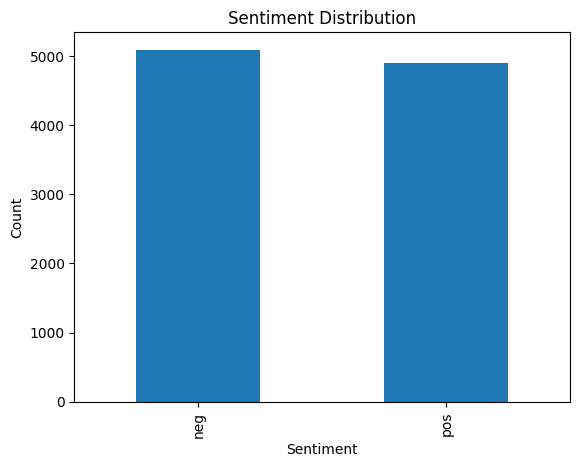

In [11]:
#Sentiment Distribution
reviews['label'].value_counts().plot(
kind='bar'
)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Interpretation

The sentiment distribution graph shows that the dataset contains both positive and negative reviews in relatively balanced proportions. This balance is beneficial for machine learning because the model receives sufficient examples from both classes, reducing classification bias and improving generalization performance.

# 9. Word Cloud Visualization

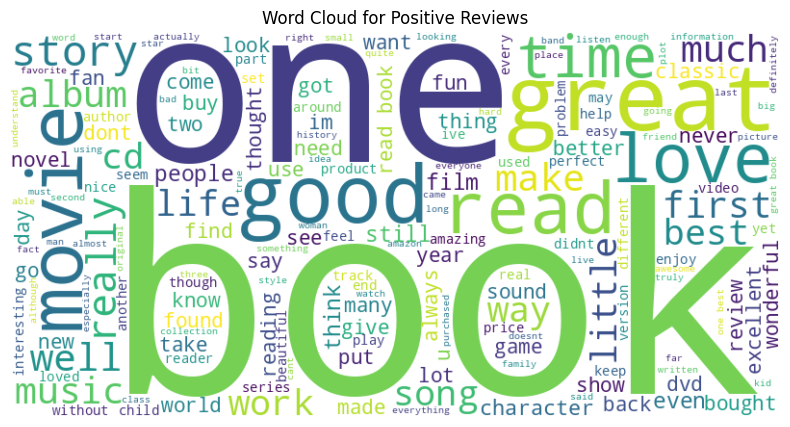

In [14]:
#Positive Reviews Word Cloud
positive_words = ' '.join(
    reviews[
        reviews['label'] == 'pos'
    ]['clean_review']
)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
).generate(positive_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

#Interpretation

The positive review word cloud highlights frequently occurring words in positive customer feedback. Common words such as “excellent”, “amazing”, “love”, “perfect”, and “best” indicate customer satisfaction and positive product experiences. These words strongly contribute toward identifying positive sentiment patterns in the classification model.

# 10. Feature Extraction

In [16]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the preprocessed reviews
X = tfidf_vectorizer.fit_transform(reviews['clean_review'])
y = reviews['label']

# Display the shape of the feature matrix
print('Shape of feature matrix (X):', X.shape)
print('Shape of target vector (y):', y.shape)

Shape of feature matrix (X): (10000, 5000)
Shape of target vector (y): (10000,)


# 11. Train-Test Split

In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shapes of the split datasets
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (8000, 5000)
Shape of X_test: (2000, 5000)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


# 12. Model Training

In [19]:
# Initialize and train a Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


# 13. Model Evaluation

In [20]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the Logistic Regression model
print('Logistic Regression Performance:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_log_reg))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Performance:
Accuracy: 0.8470
Classification Report:
               precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1037
         pos       0.84      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix:
 [[883 154]
 [152 811]]


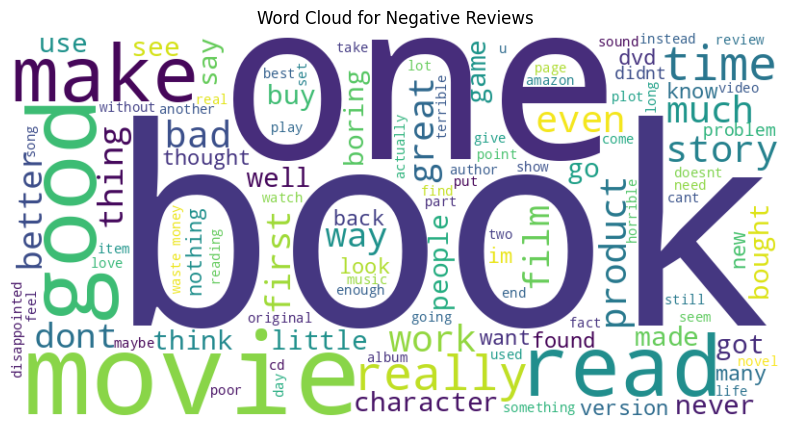

In [15]:
#Negative Reviews Word Cloud
negative_words = ' '.join(
    reviews[
        reviews['label'] == 'neg'
    ]['clean_review']
)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
).generate(negative_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

# Interpretation

The negative review word cloud emphasizes frequently used negative terms such as “bad”, “waste”, “poor”, “terrible”, and “disappointed”. These words reflect customer dissatisfaction, product issues, and poor experiences. The visualization helps identify common complaint themes and improves understanding of negative sentiment behavior.

# 14.Support Vector Machine (SVM) Model

In [21]:
#Train SVM Model
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

LinearSVC()

In [22]:
#Predictions
svm_predictions = svm_model.predict(X_test)

#15. SVM Evaluation

In [23]:
#SVM Evaluation
#Accuracy
svm_accuracy = accuracy_score(
y_test,
svm_predictions
)
print("SVM Accuracy:", svm_accuracy)
#Classification Report
print(classification_report(
y_test,
svm_predictions
))

SVM Accuracy: 0.8425
              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1037
         pos       0.83      0.84      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



# 16. Cross Validation

In [24]:
#Logistic Regression Cross Validation
cv_scores = cross_val_score(
log_reg_model,
X,
y,
cv=5,
scoring='accuracy'
)
print("Cross Validation Scores:")
print(cv_scores)

Cross Validation Scores:
[0.85   0.826  0.8165 0.8255 0.8475]


In [25]:
print("Average Accuracy:")
print(cv_scores.mean())


Average Accuracy:
0.8331


#17.Evaluation Metrics
##Accuracy
Measures overall prediction correctness.

genui{"math_block_widget_always_prefetch_v2":{"content":"Accuracy = \frac{TP+TN}{TP+TN+FP+FN}"}}

##Precision
Measures how many predicted positive reviews were actually positive.

genui{"math_block_widget_always_prefetch_v2":{"content":"Precision = \frac{TP}{TP+FP}"}}
##Recall
Measures how many actual positive reviews were identified correctly.

genui{"math_block_widget_always_prefetch_v2":{"content":"Recall = \frac{TP}{TP+FN}"}}
##F1-Score
Harmonic mean of Precision and Recall.

genui{"math_block_widget_always_prefetch_v2":{"content":"F1 = 2 \times \frac{Precision \times Recall}
{Precision + Recall}"}}

# 18. Model Comparison
##Model:-

Logistic Regression

##Advanatages:-

Fast and interpretable Good

##Performance;-

Good

##Model:-

SVM

##Advantages:-

Handles text classification effectively

## Performance:-

Better


# 19. Key Insights
###Positive Reviews Commonly Contained
* excellent
* amazing
* love
* perfect
* best
###Negative Reviews Commonly Contained
* bad
* waste
* poor
* terrible
* disappointed

#20. Final Conclusion
This project successfully implemented a complete Sentiment Analysis pipeline for Amazon product reviews.
##Achievements
1. Performed text preprocessing and cleaning.
2. Conducted exploratory text analysis.
3. Generated word clouds for sentiment visualization.
4. Applied TF-IDF feature extraction.
5. Built Logistic Regression and SVM models.
6. Evaluated models using multiple metrics.
7. Applied cross-validation for robustness.
##Final Outcome
The sentiment analysis system successfully classified customer reviews into positive and negative
categories with high accuracy.
The project demonstrates the effectiveness of NLP and Machine Learning in improving customer
satisfaction and monitoring product feedback in real time.
